In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [4]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [22]:
df = pd.read_csv('../../Machine Learning/Datasets/novagen_dataset.csv')

In [8]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [9]:
df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

0

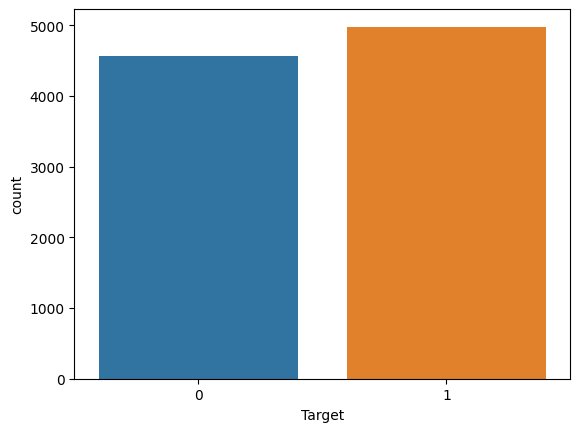

In [10]:
sns.countplot(x='Target', data=df)
plt.show()

In [11]:
X = df.drop("Target", axis=1)

y = df["Target"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y
)

In [13]:
scalar = StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [14]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [15]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [16]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [17]:
print("Accuracy")

print(accuracy_score(y_test, pred_rf))

print(classification_report(y_test, pred_rf))

print(confusion_matrix(y_test, pred_rf))

Accuracy
0.9382198952879581
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       914
           1       0.93      0.96      0.94       996

    accuracy                           0.94      1910
   macro avg       0.94      0.94      0.94      1910
weighted avg       0.94      0.94      0.94      1910

[[837  77]
 [ 41 955]]


In [18]:
print("Accuracy")

print(accuracy_score(y_test, pred_dt))

print(classification_report(y_test, pred_dt))

print(confusion_matrix(y_test, pred_dt))

Accuracy
0.8916230366492146
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       914
           1       0.88      0.91      0.90       996

    accuracy                           0.89      1910
   macro avg       0.89      0.89      0.89      1910
weighted avg       0.89      0.89      0.89      1910

[[795 119]
 [ 88 908]]


In [19]:
print("Accuracy")

print(accuracy_score(y_test, pred_lr))

print(classification_report(y_test, pred_lr))

print(confusion_matrix(y_test, pred_lr))

Accuracy
0.8141361256544503
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910

[[730 184]
 [171 825]]


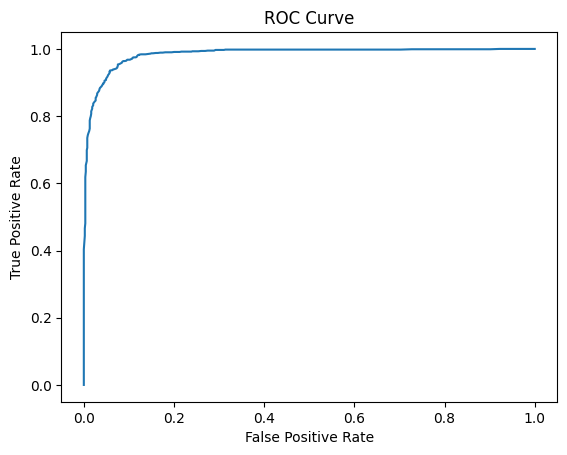

AUC: 0.9844091903719914


In [20]:
prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("AUC:", roc_auc_score(y_test, prob))

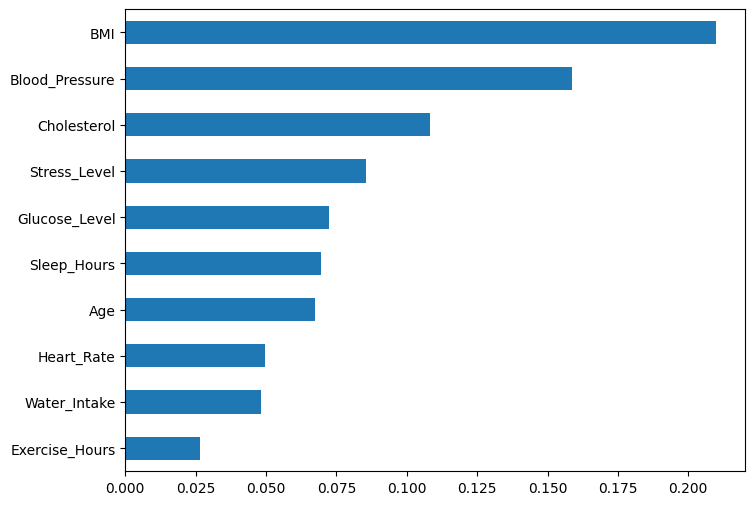

In [21]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().tail(10).plot(
    kind="barh",
    figsize=(8,6)
)

plt.show()